# 🥇 Project 2: Gold Price Prediction using GRU (Gated Recurrent Unit)

---

## 📌 Project Overview

**Goal:** Predict the next day's gold closing price using the last 60 days of price history.

**Model Used:** GRU (Gated Recurrent Unit) — a type of Recurrent Neural Network (RNN)

**Dataset:** Synthetically generated gold price data mimicking real 10-year XAUUSD market data patterns

---

## 📚 Theoretical Background

### 🔹 What is a Recurrent Neural Network (RNN)?

A **Recurrent Neural Network** is a type of neural network designed specifically for **sequential data** (time series, text, speech). Unlike a regular neural network that forgets previous inputs, an RNN maintains a **hidden state** that carries memory of past inputs.

| Feature | Regular Neural Network (ANN/DNN) | Recurrent Neural Network (RNN) |
|---|---|---|
| **Memory** | No memory of past inputs | Maintains memory via hidden state |
| **Input Type** | Fixed-size, independent | Sequential, dependent on history |
| **Best for** | Tabular data, images | Time series, text, speech |
| **Problem** | — | Vanishing gradient (forgets long history) |

---

### 🔹 What is LSTM vs GRU?

Both LSTM and GRU were created to solve the **vanishing gradient problem** of basic RNNs.

| Feature | LSTM (Long Short-Term Memory) | GRU (Gated Recurrent Unit) |
|---|---|---|
| **Proposed by** | Hochreiter & Schmidhuber, 1997 | Cho et al., 2014 |
| **Gates** | 3 gates: Input, Output, Forget | 2 gates: Update, Reset |
| **Memory** | Separate cell state + hidden state | Combined into one hidden state |
| **Speed** | Slower to train | Faster to train (fewer parameters) |
| **Performance** | Better on very long sequences | Comparable, often better on shorter sequences |
| **Parameters** | More parameters | Fewer parameters |
| **Use Case** | When long-term memory matters a lot | When speed and efficiency matter |

---

### 🔹 GRU Gates Explained Simply

| Gate | Purpose | Simple Analogy |
|---|---|---|
| **Update Gate (z)** | Decides how much past memory to keep | "How much do I remember from yesterday?" |
| **Reset Gate (r)** | Decides how much past info to forget | "Should I forget old gold price trends?" |
| **New Memory** | Creates candidate new hidden state | "What's the new information from today?" |

---

### 🔹 What is the Sliding Window Technique?

Gold price at time T depends on prices at T-1, T-2, ... T-60. We create sequences of **window_size=60** days as input, and predict day 61.

```
Input  → [Day1, Day2, ..., Day60] → Output → Day61
Input  → [Day2, Day3, ..., Day61] → Output → Day62
Input  → [Day3, Day4, ..., Day62] → Output → Day63
```

---

### 🔹 Why Scale the Data?

| Reason | Explanation |
|---|---|
| **Neural networks are sensitive to scale** | Gold price ~$1800 vs sigmoid output ~0 to 1 → huge mismatch |
| **Faster convergence** | Scaled data makes gradient descent work efficiently |
| **MinMaxScaler** | Squishes all values between 0 and 1 |
| **Must inverse transform predictions** | After prediction, multiply back to get actual price |

---

### 🔹 Evaluation Metrics

| Metric | Formula | Interpretation |
|---|---|---|
| **MAE** | Mean of |actual - predicted| | Average dollar error in prediction |
| **RMSE** | √(Mean of (actual-predicted)²) | Punishes large prediction errors more |
| **MAPE** | Mean of |(actual-predicted)/actual| × 100% | % error — very intuitive |
| **R²** | 1 - SS_res/SS_tot | 0.95 means model explains 95% of price movements |

In [ ]:
# ============================================================
# 📦 STEP 1: INSTALL AND IMPORT ALL REQUIRED LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras for building the GRU model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential          # Sequential model
from tensorflow.keras.layers import GRU, Dense, Dropout # GRU layer, Dropout for regularization
from tensorflow.keras.callbacks import EarlyStopping    # Stop training when no improvement
from tensorflow.keras.callbacks import ReduceLROnPlateau  # Reduce learning rate

# Sklearn for data preprocessing and evaluation
from sklearn.preprocessing import MinMaxScaler         # Scale data to [0, 1]
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("✅ All libraries imported successfully!")
print(f"   TensorFlow version: {tf.__version__}")

✅ All libraries imported successfully!
   TensorFlow version: 2.20.0


In [ ]:
# ============================================================
# 📊 STEP 2: GENERATE REALISTIC SYNTHETIC GOLD PRICE DATA
# ============================================================
# Simulating 10 years of daily gold prices (2014–2023)
# Based on real gold market characteristics:
#   - Long-term upward trend
#   - COVID spike (2020), Inflation spike (2022)
#   - Daily volatility

np.random.seed(42)

# Create date range: only weekdays (markets don't open on weekends)
date_range = pd.bdate_range(start='2014-01-01', end='2023-12-31')  # Business days only
n          = len(date_range)
print(f"📅 Total trading days: {n} (spanning 10 years)")

# --- Simulate Gold Price using Geometric Brownian Motion (GBM) ---
# GBM is the standard financial model for asset prices (same as Black-Scholes)
# price(t+1) = price(t) * exp(drift + volatility * random_shock)

S0          = 1250.0      # Starting price: $1250/oz in Jan 2014
daily_drift = 0.00018     # Small upward bias (gold trends up over time)
volatility  = 0.009       # Daily volatility: ~0.9% per day (realistic for gold)

prices = [S0]             # Start with initial price

for i in range(1, n):
    # Generate random daily return
    random_shock = np.random.normal(0, 1)         # Standard normal random variable
    daily_return = daily_drift + volatility * random_shock

    # Add trend-based jumps for specific events
    year  = date_range[i].year
    month = date_range[i].month

    # COVID-19 impact: Gold spiked strongly in 2020 (safe-haven buying)
    if year == 2020 and month >= 3 and month <= 9:
        daily_return += 0.0008     # Extra upward push

    # Post-COVID correction in late 2020
    if year == 2020 and month >= 10:
        daily_return -= 0.0003

    # Russia-Ukraine & inflation spike: Gold surged in early 2022
    if year == 2022 and month <= 4:
        daily_return += 0.0006

    # Fed rate hikes pressure gold downward in late 2022
    if year == 2022 and month >= 6:
        daily_return -= 0.0004

    # Calculate next price using GBM formula
    next_price = prices[-1] * np.exp(daily_return)
    prices.append(next_price)

# Create DataFrame
gold_df = pd.DataFrame({
    'Date' : date_range,
    'Close': np.round(prices, 2)
})
gold_df.set_index('Date', inplace=True)

# Add Open, High, Low, Volume to make it more realistic
gold_df['Open']   = gold_df['Close'].shift(1).fillna(gold_df['Close'][0])  # Yesterday's close
gold_df['High']   = gold_df['Close'] + np.random.uniform(2, 15, n)          # Close + small premium
gold_df['Low']    = gold_df['Close'] - np.random.uniform(2, 15, n)          # Close - small discount
gold_df['Volume'] = np.random.randint(50000, 200000, n)                      # Simulated trade volume

print(f"\n📋 First 5 rows:")
print(gold_df.head())
print(f"\n📋 Last 5 rows:")
print(gold_df.tail())

📅 Total trading days: 2608 (spanning 10 years)

📋 First 5 rows:
              Close     Open         High          Low  Volume
Date                                                          
2014-01-01  1250.00  1250.00  1261.395591  1244.289747  141080
2014-01-02  1255.83  1250.00  1266.367483  1246.214491  105828
2014-01-03  1254.49  1255.83  1265.703954  1251.066729  166884
2014-01-06  1262.05  1254.49  1264.158728  1247.494123  158007
2014-01-07  1279.70  1262.05  1284.529676  1275.427795   96104

📋 Last 5 rows:
              Close     Open         High          Low  Volume
Date                                                          
2023-12-25  4781.76  4808.32  4789.206007  4774.242943   61952
2023-12-26  4731.69  4781.76  4740.414538  4727.652082  133323
2023-12-27  4706.02  4731.69  4709.114769  4698.476721  192712
2023-12-28  4699.06  4706.02  4713.859487  4690.073580   76437
2023-12-29  4674.39  4699.06  4685.053295  4672.097444  177129


In [ ]:
# ============================================================
# 🔍 STEP 3: BASIC DATA EXPLORATION (EDA Part 1)
# ============================================================

print("=" * 60)
print("📐 DATASET SHAPE")
print(f"Rows: {gold_df.shape[0]}, Columns: {gold_df.shape[1]}")

print("\n" + "=" * 60)
print("📝 DTYPES")
print(gold_df.dtypes)

print("\n" + "=" * 60)
print("🚨 MISSING VALUES")
print(gold_df.isnull().sum())

print("\n" + "=" * 60)
print("📊 STATISTICAL SUMMARY")
print(gold_df.describe().round(2))

print("\n" + "=" * 60)
print("💡 KEY OBSERVATIONS:")
print(f"  - Starting price  (2014): ${gold_df['Close'].iloc[0]:,.2f}")
print(f"  - Ending price    (2023): ${gold_df['Close'].iloc[-1]:,.2f}")
print(f"  - All-time High          : ${gold_df['Close'].max():,.2f} on {gold_df['Close'].idxmax().strftime('%b %d, %Y')}")
print(f"  - All-time Low           : ${gold_df['Close'].min():,.2f} on {gold_df['Close'].idxmin().strftime('%b %d, %Y')}")
print(f"  - Total price increase   : ${gold_df['Close'].iloc[-1] - gold_df['Close'].iloc[0]:,.2f}")
print(f"  - Total % return (10yr)  : {((gold_df['Close'].iloc[-1]/gold_df['Close'].iloc[0])-1)*100:.1f}%")

📐 DATASET SHAPE
Rows: 2608, Columns: 5

📝 DTYPES
Close     float64
Open      float64
High      float64
Low       float64
Volume      int64
dtype: object

🚨 MISSING VALUES
Close     0
Open      0
High      0
Low       0
Volume    0
dtype: int64

📊 STATISTICAL SUMMARY
         Close     Open     High      Low     Volume
count  2608.00  2608.00  2608.00  2608.00    2608.00
mean   2736.74  2735.43  2745.19  2728.40  123786.48
std    1295.56  1295.33  1295.58  1295.63   43880.80
min    1127.84  1127.84  1137.20  1116.14   50005.00
25%    1387.73  1387.19  1395.79  1378.08   85574.75
50%    2443.66  2443.00  2451.08  2436.70  123407.50
75%    4162.60  4161.94  4170.71  4156.22  161982.25
max    4994.39  4994.39  4999.59  4979.75  199979.00

💡 KEY OBSERVATIONS:
  - Starting price  (2014): $1,250.00
  - Ending price    (2023): $4,674.39
  - All-time High          : $4,994.39 on Nov 29, 2023
  - All-time Low           : $1,127.84 on May 28, 2014
  - Total price increase   : $3,424.39
  - Total 

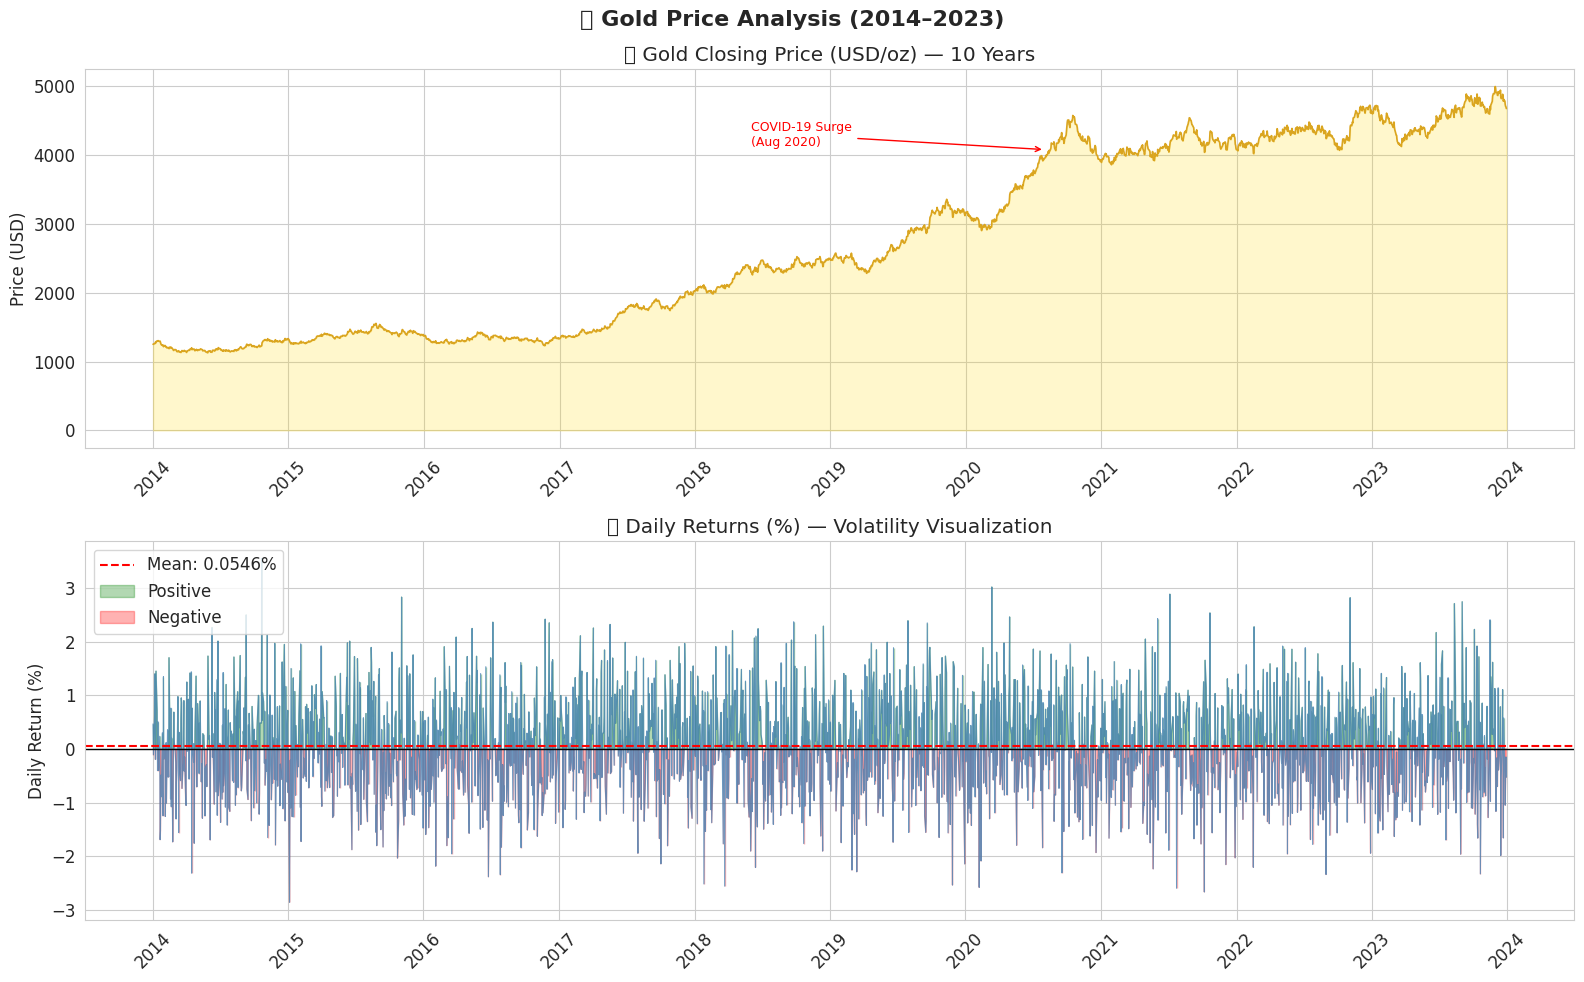


💡 Daily Return Stats:
  - Avg daily return : 0.0546%
  - Max gain in 1 day: +3.55%
  - Max loss in 1 day: -2.86%


In [ ]:
# ============================================================
# 📈 STEP 4: GOLD PRICE FULL TIMELINE VISUALIZATION (EDA Part 2)
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('🥇 Gold Price Analysis (2014–2023)', fontsize=16, fontweight='bold')

# --- Plot 1: Full price history ---
axes[0].plot(gold_df.index, gold_df['Close'], color='goldenrod', linewidth=1.2)
axes[0].fill_between(gold_df.index, gold_df['Close'], alpha=0.2, color='gold')
axes[0].set_title('📈 Gold Closing Price (USD/oz) — 10 Years')
axes[0].set_ylabel('Price (USD)')

# Annotate key events
axes[0].annotate('COVID-19 Surge\n(Aug 2020)',
                 xy=(pd.Timestamp('2020-08-01'), gold_df.loc['2020-08', 'Close'].mean()),
                 xytext=(pd.Timestamp('2018-06-01'), gold_df.loc['2020-08', 'Close'].mean() + 50),
                 fontsize=9, color='red',
                 arrowprops=dict(arrowstyle='->', color='red'))

axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].xaxis.set_major_locator(mdates.YearLocator())
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# --- Plot 2: Daily Returns (Percentage Change) ---
daily_returns = gold_df['Close'].pct_change() * 100   # Percentage change each day
axes[1].plot(gold_df.index, daily_returns, color='steelblue', linewidth=0.8, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].axhline(daily_returns.mean(), color='red', linestyle='--', label=f'Mean: {daily_returns.mean():.4f}%')
axes[1].fill_between(gold_df.index, daily_returns, where=(daily_returns > 0), color='green', alpha=0.3, label='Positive')
axes[1].fill_between(gold_df.index, daily_returns, where=(daily_returns < 0), color='red', alpha=0.3, label='Negative')
axes[1].set_title('📉 Daily Returns (%) — Volatility Visualization')
axes[1].set_ylabel('Daily Return (%)')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator())
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

print(f"\n💡 Daily Return Stats:")
print(f"  - Avg daily return : {daily_returns.mean():.4f}%")
print(f"  - Max gain in 1 day: +{daily_returns.max():.2f}%")
print(f"  - Max loss in 1 day: {daily_returns.min():.2f}%")

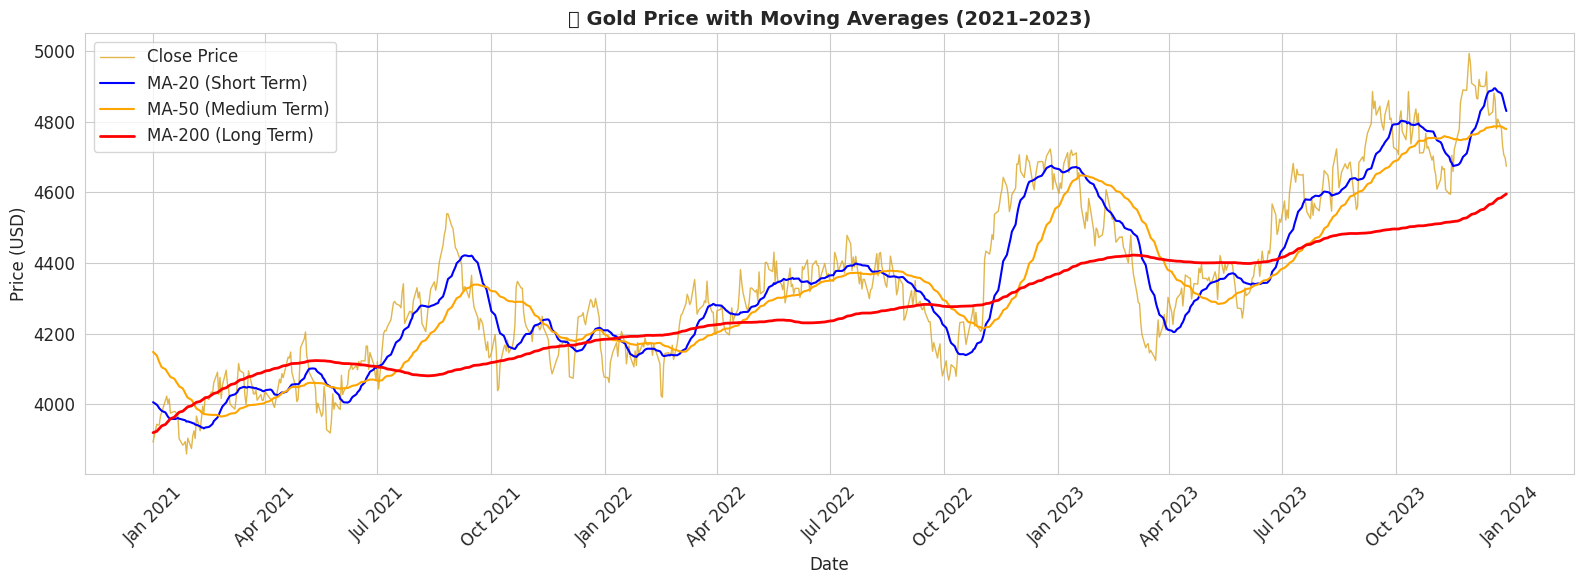

💡 Trading Signal Interpretation:
  - Price ABOVE MA200 → Bullish (uptrend)
  - Price BELOW MA200 → Bearish (downtrend)
  - MA20 crossing ABOVE MA50 → Golden Cross (buy signal)
  - MA20 crossing BELOW MA50 → Death Cross (sell signal)


In [ ]:
# ============================================================
# 📊 STEP 5: MOVING AVERAGES ANALYSIS (EDA Part 3)
# ============================================================
# Moving averages smooth out noise and reveal underlying trend
# MA20 = average of last 20 days (short-term trend)
# MA50 = average of last 50 days (medium-term trend)
# MA200= average of last 200 days (long-term trend)

# Calculate moving averages
gold_df['MA_20']  = gold_df['Close'].rolling(window=20).mean()   # 20-day MA
gold_df['MA_50']  = gold_df['Close'].rolling(window=50).mean()   # 50-day MA
gold_df['MA_200'] = gold_df['Close'].rolling(window=200).mean()  # 200-day MA

# Plot last 3 years for clarity
plot_start = '2021-01-01'
gold_recent = gold_df[plot_start:]

plt.figure(figsize=(16, 6))
plt.plot(gold_recent.index, gold_recent['Close'],  color='goldenrod', linewidth=1.0, alpha=0.8, label='Close Price')
plt.plot(gold_recent.index, gold_recent['MA_20'],  color='blue',      linewidth=1.5, label='MA-20 (Short Term)')
plt.plot(gold_recent.index, gold_recent['MA_50'],  color='orange',    linewidth=1.5, label='MA-50 (Medium Term)')
plt.plot(gold_recent.index, gold_recent['MA_200'], color='red',       linewidth=2.0, label='MA-200 (Long Term)')
plt.title('📊 Gold Price with Moving Averages (2021–2023)', fontsize=14, fontweight='bold')
plt.ylabel('Price (USD)')
plt.xlabel('Date')
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("💡 Trading Signal Interpretation:")
print("  - Price ABOVE MA200 → Bullish (uptrend)")
print("  - Price BELOW MA200 → Bearish (downtrend)")
print("  - MA20 crossing ABOVE MA50 → Golden Cross (buy signal)")
print("  - MA20 crossing BELOW MA50 → Death Cross (sell signal)")

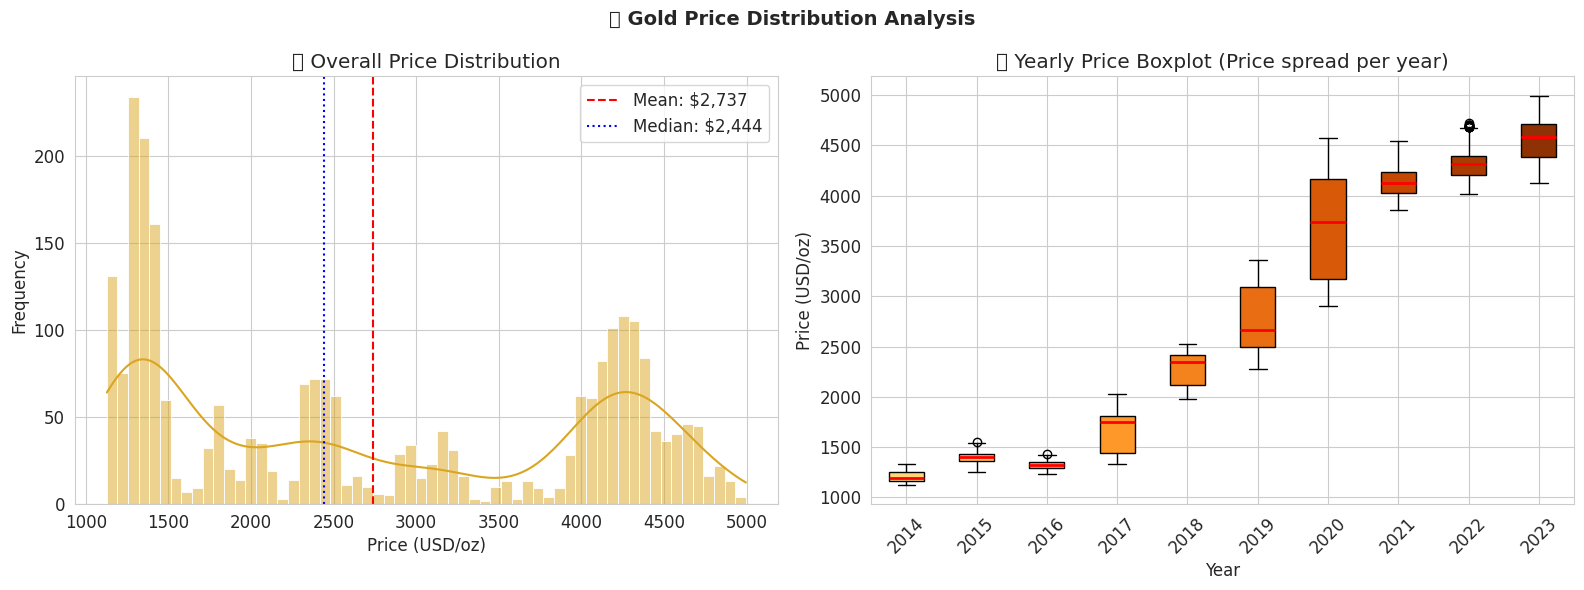

In [ ]:
# ============================================================
# 📊 STEP 6: DISTRIBUTION AND BOXPLOT ANALYSIS (EDA Part 4)
# ============================================================

gold_df['Year'] = gold_df.index.year   # Extract year for boxplot grouping

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('📊 Gold Price Distribution Analysis', fontsize=14, fontweight='bold')

# --- Left: Overall distribution ---
sns.histplot(gold_df['Close'], bins=60, kde=True, color='goldenrod', ax=axes[0])
axes[0].axvline(gold_df['Close'].mean(), color='red', linestyle='--',
                label=f"Mean: ${gold_df['Close'].mean():,.0f}")
axes[0].axvline(gold_df['Close'].median(), color='blue', linestyle=':',
                label=f"Median: ${gold_df['Close'].median():,.0f}")
axes[0].set_title('📊 Overall Price Distribution')
axes[0].set_xlabel('Price (USD/oz)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# --- Right: Yearly boxplot ---
yearly_data = [gold_df[gold_df['Year'] == yr]['Close'].values for yr in range(2014, 2024)]
bp = axes[1].boxplot(yearly_data,
                     labels=[str(yr) for yr in range(2014, 2024)],
                     patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))

# Color each box differently
colors = plt.cm.YlOrBr(np.linspace(0.3, 0.9, 10))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

axes[1].set_title('📦 Yearly Price Boxplot (Price spread per year)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Price (USD/oz)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 🔧 STEP 7: DATA PREPROCESSING — SCALING
# ============================================================
# Neural networks work best with data in range [0, 1]
# MinMaxScaler: X_scaled = (X - X_min) / (X_max - X_min)

# We only predict the 'Close' price
close_prices = gold_df[['Close']].copy()   # Keep as 2D (needed for scaler)

# Create the scaler
scaler = MinMaxScaler(feature_range=(0, 1))   # Output will be in [0, 1]

# Fit scaler to ALL data (find min and max)
# Then transform to scaled values
scaled_data = scaler.fit_transform(close_prices)

print(f"📊 Original price range: ${close_prices['Close'].min():,.2f} – ${close_prices['Close'].max():,.2f}")
print(f"✅ Scaled price range:   {scaled_data.min():.4f} – {scaled_data.max():.4f}")
print(f"\n📋 First 5 scaled values: {scaled_data[:5].flatten().round(4)}")

📊 Original price range: $1,127.84 – $4,994.39
✅ Scaled price range:   0.0000 – 1.0000

📋 First 5 scaled values: [0.0316 0.0331 0.0328 0.0347 0.0393]


In [ ]:
# ============================================================
# 🔧 STEP 8: CREATE SLIDING WINDOW SEQUENCES
# ============================================================
# For each sample:
#   Input X: 60 consecutive days of scaled gold price
#   Output y: The 61st day's scaled price
# This is the sequence-to-one prediction approach

WINDOW_SIZE = 60    # Use last 60 days (about 3 months of trading)

X_all = []   # Will store all input sequences
y_all = []   # Will store all target values

# Loop through the data to create sequences
for i in range(WINDOW_SIZE, len(scaled_data)):
    # Input: scaled prices from (i-60) to (i-1) → shape (60, 1)
    X_all.append(scaled_data[i - WINDOW_SIZE : i, 0])
    # Target: scaled price at position i
    y_all.append(scaled_data[i, 0])

# Convert lists to numpy arrays
X_all = np.array(X_all)   # Shape: (total_samples, 60)
y_all = np.array(y_all)   # Shape: (total_samples,)

# Reshape X for GRU: must be 3D → (samples, timesteps, features)
# features = 1 because we only use Close price
X_all = X_all.reshape(X_all.shape[0], X_all.shape[1], 1)

print(f"✅ Sliding window creation complete!")
print(f"   Window size     : {WINDOW_SIZE} days")
print(f"   Total samples   : {X_all.shape[0]}")
print(f"   X shape (3D)    : {X_all.shape}  → (samples, timesteps, features)")
print(f"   y shape         : {y_all.shape}  → (samples,)")

✅ Sliding window creation complete!
   Window size     : 60 days
   Total samples   : 2548
   X shape (3D)    : (2548, 60, 1)  → (samples, timesteps, features)
   y shape         : (2548,)  → (samples,)


In [ ]:
# ============================================================
# ✂️ STEP 9: TRAIN-TEST SPLIT
# ============================================================
# Time series: NO shuffling! Train on past, test on future.

train_ratio = 0.80   # 80% for training
total       = len(X_all)
split_idx   = int(total * train_ratio)

# Split sequentially — no shuffling
X_train = X_all[:split_idx]
X_test  = X_all[split_idx:]
y_train = y_all[:split_idx]
y_test  = y_all[split_idx:]

print(f"📊 Total sequence samples : {total}")
print(f"🟢 Training samples       : {X_train.shape[0]} ({train_ratio*100:.0f}%)")
print(f"🔴 Testing samples        : {X_test.shape[0]}  ({(1-train_ratio)*100:.0f}%)")
print(f"\n   X_train shape: {X_train.shape}  →  (samples, 60 days, 1 feature)")
print(f"   X_test  shape: {X_test.shape}")
print(f"   y_train shape: {y_train.shape}")
print(f"   y_test  shape: {y_test.shape}")

📊 Total sequence samples : 2548
🟢 Training samples       : 2038 (80%)
🔴 Testing samples        : 510  (20%)

   X_train shape: (2038, 60, 1)  →  (samples, 60 days, 1 feature)
   X_test  shape: (510, 60, 1)
   y_train shape: (2038,)
   y_test  shape: (510,)


In [ ]:
# ============================================================
# 🏗️ STEP 10: BUILD THE GRU MODEL
# ============================================================
# Architecture: GRU → Dropout → GRU → Dropout → Dense → Dense
#
# Layer-by-layer explanation:
#   GRU(128, return_sequences=True)  → First GRU, outputs all timesteps (needed for stacking)
#   Dropout(0.2)                     → Randomly drops 20% neurons during training (prevents overfitting)
#   GRU(64, return_sequences=False)  → Second GRU, outputs only final timestep
#   Dropout(0.2)                     → Another dropout layer
#   Dense(32, relu)                  → Fully connected hidden layer
#   Dense(1)                         → Final output: single predicted price

model = Sequential(name='GRU_Gold_Price_Predictor')

# Layer 1: First GRU Layer
# input_shape=(60, 1) means: 60 timesteps, 1 feature per timestep
# return_sequences=True: pass all 60 hidden states to next GRU layer
# units=128: number of GRU neurons (higher = more capacity)
model.add(GRU(
    units=128,
    return_sequences=True,       # Send all timesteps to next layer
    input_shape=(WINDOW_SIZE, 1) # (60 days, 1 feature)
))

# Dropout: randomly set 20% of neurons to zero during training
# This forces model to not rely on any single neuron → reduces overfitting
model.add(Dropout(0.2))

# Layer 2: Second GRU Layer
# return_sequences=False: only output the LAST hidden state
model.add(GRU(
    units=64,
    return_sequences=False       # Only final timestep output
))

model.add(Dropout(0.2))

# Layer 3: Dense hidden layer (regular neural network layer)
# activation='relu': Rectified Linear Unit — sets negative values to 0
model.add(Dense(units=32, activation='relu'))

# Layer 4: Output layer — predicts ONE value (next day price, scaled)
# No activation → linear output (default for regression)
model.add(Dense(units=1))

# Compile: Choose optimizer and loss function
# Adam optimizer: adaptive learning rate (works well in practice)
# MSE loss: appropriate for regression (predicting a number)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']              # Also track MAE during training
)

print("🏗️ GRU Model Architecture:")
model.summary()

🏗️ GRU Model Architecture:


Model: "GRU_Gold_Price_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 128)        │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,665 (350.25 KB)

 Trainable params: 89,665 (350.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# 🚀 STEP 11: TRAIN THE GRU MODEL
# ============================================================

# --- Callbacks ---
# 1. EarlyStopping: Stop training when val_loss stops improving
#    patience=15 → wait 15 more epochs before stopping
#    restore_best_weights → revert to best model found during training
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# 2. ReduceLROnPlateau: Reduce learning rate when validation loss plateaus
#    factor=0.5 → multiply lr by 0.5
#    patience=7  → wait 7 epochs before reducing
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

print("🚀 Training GRU model...")
print(f"   Training samples : {X_train.shape[0]}")
print(f"   Batch size       : 32")
print(f"   Max epochs       : 100 (with early stopping)")
print(f"   Validation split : 10% of training data")
print()

history = model.fit(
    X_train, y_train,            # Training data
    batch_size=32,               # Process 32 samples at a time
    epochs=100,                  # Max 100 epochs (early stopping may stop earlier)
    validation_split=0.10,       # Use 10% of train data for validation
    callbacks=[early_stop, reduce_lr],
    verbose=1                    # Show training progress
)

print(f"\n✅ Training complete!")
print(f"   Epochs trained: {len(history.history['loss'])}")
print(f"   Final train loss    : {history.history['loss'][-1]:.6f}")
print(f"   Final val loss      : {history.history['val_loss'][-1]:.6f}")

🚀 Training GRU model...
   Training samples : 2038
   Batch size       : 32
   Max epochs       : 100 (with early stopping)
   Validation split : 10% of training data

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - loss: 0.0061 - mae: 0.0461 - val_loss: 3.7538e-04 - val_mae: 0.0153 - learning_rate: 0.0010
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 138ms/step - loss: 0.0012 - mae: 0.0213 - val_loss: 2.8174e-04 - val_mae: 0.0142 - learning_rate: 0.0010
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - loss: 8.8981e-04 - mae: 0.0192 - val_loss: 2.1041e-04 - val_mae: 0.0119 - learning_rate: 0.0010
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 12s 149ms/step - loss: 8.0128e-04 - mae: 0.0182 - val_loss: 2.2267e-04 - val_mae: 0.0119 - learning_rate: 0.0010
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - loss: 7.4309e-04 - mae: 0.0180 - val_loss: 2.1351e-04 - val_mae: 0.0120 - learning_rate: 0.0010
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 5.6346e-04 - mae: 0.015

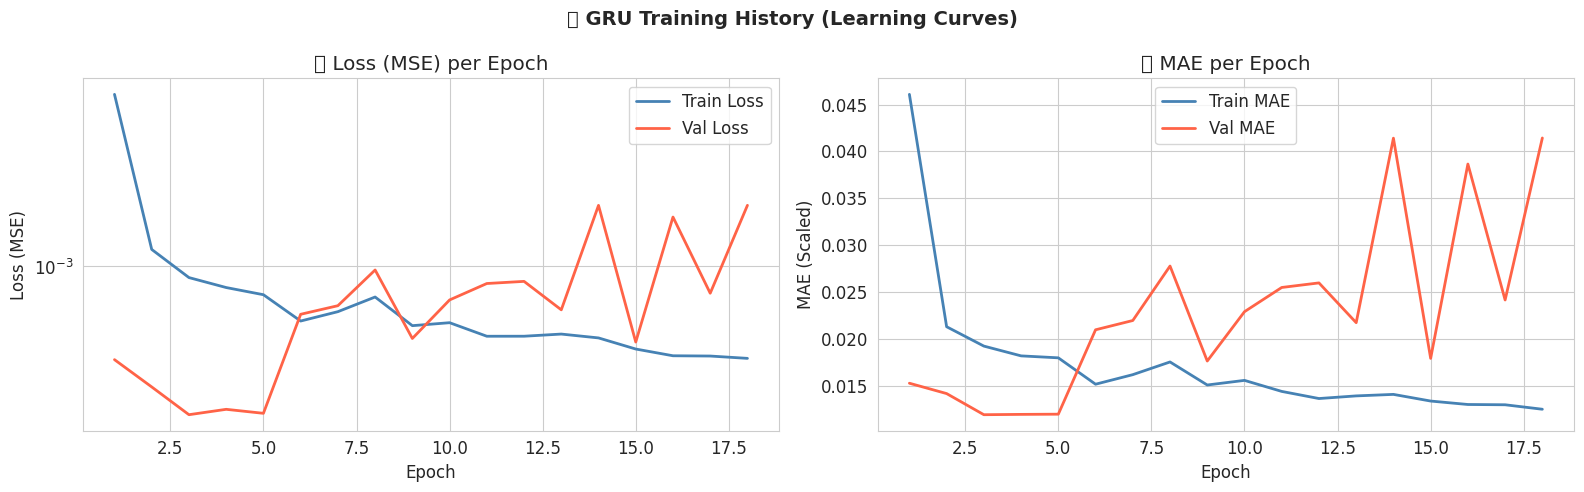

💡 Reading Learning Curves:
  - Both train and val loss decreasing → model is learning
  - Val loss MUCH higher than train loss → overfitting
  - Both converging and stable → good training


In [ ]:
# ============================================================
# 📉 STEP 12: PLOT TRAINING HISTORY (Learning Curves)
# ============================================================
# Learning curves show how well the model learned over epochs

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('📉 GRU Training History (Learning Curves)', fontsize=14, fontweight='bold')

# --- Plot 1: Loss (MSE) ---
epochs_range = range(1, len(history.history['loss']) + 1)
axes[0].plot(epochs_range, history.history['loss'],     color='steelblue', linewidth=2, label='Train Loss')
axes[0].plot(epochs_range, history.history['val_loss'], color='tomato',    linewidth=2, label='Val Loss')
axes[0].set_title('📉 Loss (MSE) per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].set_yscale('log')    # Log scale to better see small changes

# --- Plot 2: MAE ---
axes[1].plot(epochs_range, history.history['mae'],     color='steelblue', linewidth=2, label='Train MAE')
axes[1].plot(epochs_range, history.history['val_mae'], color='tomato',    linewidth=2, label='Val MAE')
axes[1].set_title('📉 MAE per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (Scaled)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("💡 Reading Learning Curves:")
print("  - Both train and val loss decreasing → model is learning")
print("  - Val loss MUCH higher than train loss → overfitting")
print("  - Both converging and stable → good training")

In [ ]:
# ============================================================
# 🔮 STEP 13: MAKE PREDICTIONS & INVERSE TRANSFORM
# ============================================================
# After predicting, we must 'inverse transform' to get actual USD prices

# Predict on test data
y_pred_scaled = model.predict(X_test, verbose=0)

# Inverse transform: convert scaled [0,1] values back to USD
# scaler.inverse_transform needs 2D input → reshape
y_pred_actual = scaler.inverse_transform(y_pred_scaled)        # Predictions in USD
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1)) # Actual values in USD

# Flatten to 1D arrays for easy comparison
y_pred_flat = y_pred_actual.flatten()
y_test_flat = y_test_actual.flatten()

print("🔮 Predictions (first 10 days):")
compare_df = pd.DataFrame({
    'Actual Price (USD)': y_test_flat[:10].round(2),
    'Predicted Price (USD)': y_pred_flat[:10].round(2),
    'Error (USD)': (y_test_flat[:10] - y_pred_flat[:10]).round(2),
    'Error (%)': ((abs(y_test_flat[:10] - y_pred_flat[:10]) / y_test_flat[:10]) * 100).round(2)
})
print(compare_df.to_string())

🔮 Predictions (first 10 days):
   Actual Price (USD)  Predicted Price (USD)  Error (USD)  Error (%)
0             4169.00            4173.250000        -4.25       0.10
1             4114.32            4177.799805       -63.47       1.54
2             4147.95            4167.890137       -19.94       0.48
3             4165.27            4161.029785         4.24       0.10
4             4134.82            4160.129883       -25.31       0.61
5             4105.78            4155.830078       -50.05       1.22
6             4150.82            4145.479980         5.34       0.13
7             4109.83            4143.509766       -33.68       0.82
8             4174.29            4137.299805        36.99       0.89
9             4143.82            4142.930176         0.89       0.02


In [ ]:
# ============================================================
# 📏 STEP 14: EVALUATE MODEL PERFORMANCE
# ============================================================

mae  = mean_absolute_error(y_test_flat, y_pred_flat)
mse  = mean_squared_error(y_test_flat, y_pred_flat)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_flat, y_pred_flat)

# MAPE
mape_values = []
for actual, predicted in zip(y_test_flat, y_pred_flat):
    if actual != 0:
        mape_values.append(abs((actual - predicted) / actual) * 100)
mape = np.mean(mape_values)

avg_gold_price = y_test_flat.mean()

print("=" * 60)
print("📏 GRU MODEL EVALUATION METRICS")
print("=" * 60)
print(f"  📌 MAE   : ${mae:.2f}  → Avg prediction error is ${mae:.2f}")
print(f"  📌 RMSE  : ${rmse:.2f}  → Penalized avg error")
print(f"  📌 MAPE  : {mape:.2f}%  → Average % error")
print(f"  📌 R²    : {r2:.4f}  → Model explains {r2*100:.1f}% of price variance")
print(f"\n  Avg gold price in test period : ${avg_gold_price:.2f}")
print(f"  MAE as % of avg price         : {(mae/avg_gold_price)*100:.2f}%")

if r2 > 0.90:
    print("\n  ✅ Excellent model! R² > 0.90")
elif r2 > 0.80:
    print("\n  ✅ Good model! R² > 0.80")
else:
    print("\n  ⚠️ Model needs improvement")

📏 GRU MODEL EVALUATION METRICS
  📌 MAE   : $41.40  → Avg prediction error is $41.40
  📌 RMSE  : $52.03  → Penalized avg error
  📌 MAPE  : 0.93%  → Average % error
  📌 R²    : 0.9425  → Model explains 94.3% of price variance

  Avg gold price in test period : $4451.28
  MAE as % of avg price         : 0.93%

  ✅ Excellent model! R² > 0.90


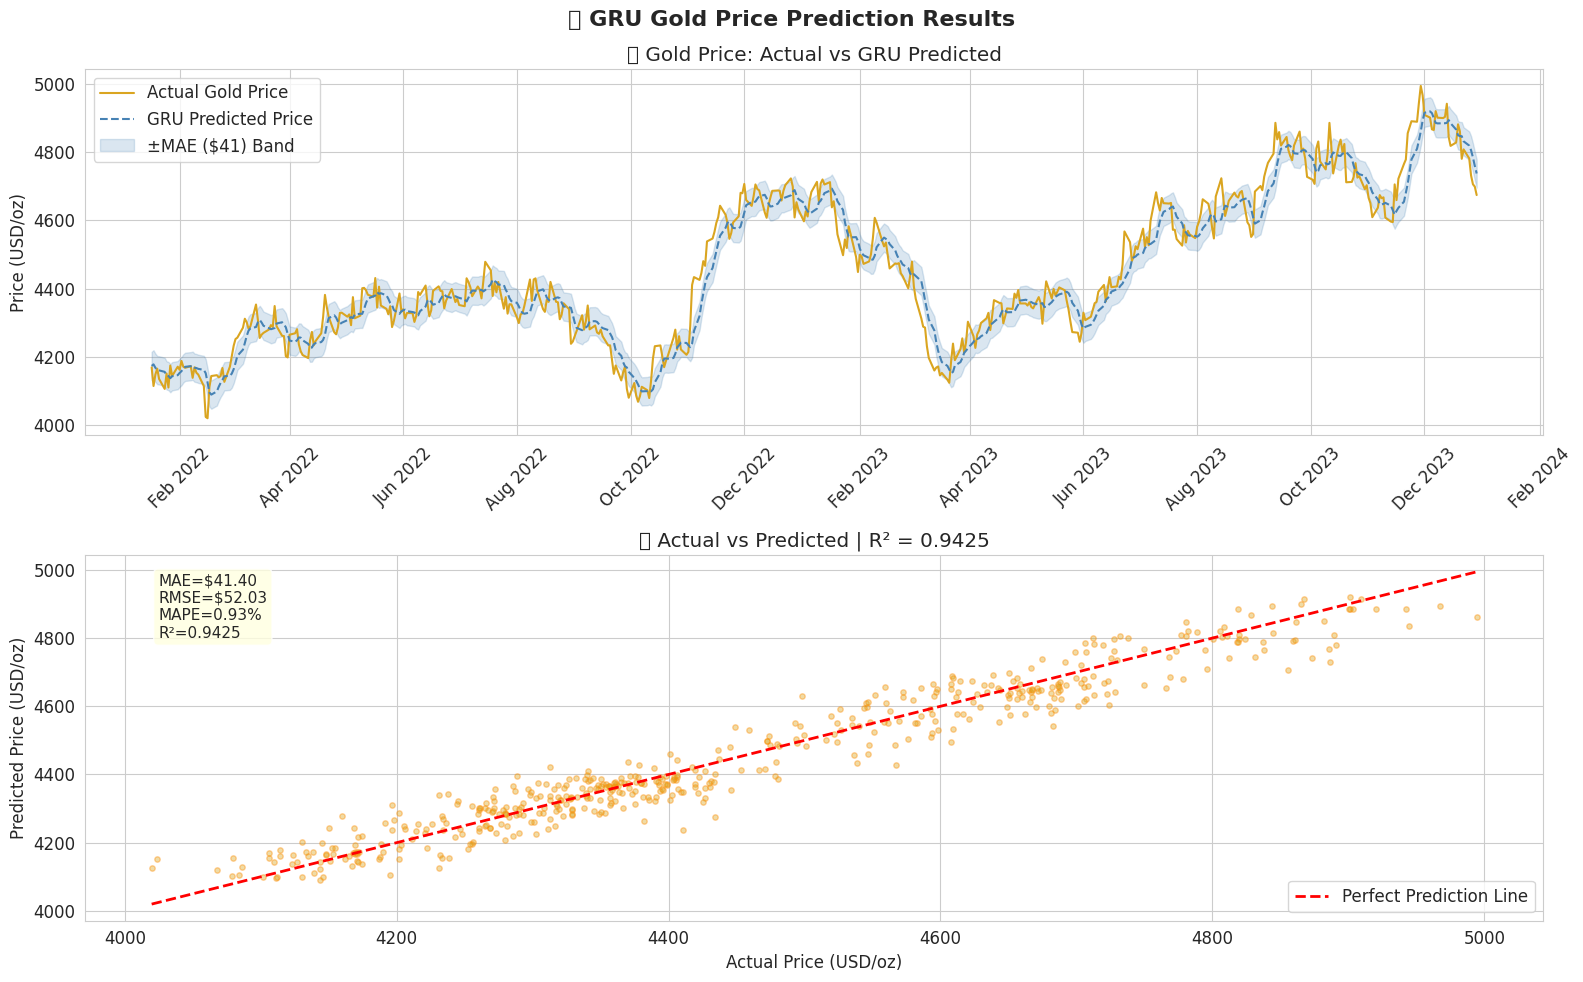

✅ Final result visualization saved!


In [ ]:
# ============================================================
# 📊 STEP 15: FINAL VISUALIZATION — ACTUAL vs PREDICTED
# ============================================================

# Get the date index for test predictions
# Test starts at (train_size + WINDOW_SIZE) index in original data
test_start_idx = split_idx + WINDOW_SIZE
test_dates     = gold_df.index[test_start_idx : test_start_idx + len(y_test_flat)]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('🥇 GRU Gold Price Prediction Results', fontsize=16, fontweight='bold')

# --- Plot 1: Actual vs Predicted on test period ---
axes[0].plot(test_dates, y_test_flat, color='goldenrod', linewidth=1.5, label='Actual Gold Price')
axes[0].plot(test_dates, y_pred_flat, color='steelblue', linewidth=1.5, linestyle='--', label='GRU Predicted Price')
axes[0].fill_between(test_dates,
                     y_pred_flat - mae,
                     y_pred_flat + mae,
                     alpha=0.2, color='steelblue',
                     label=f'±MAE (${mae:.0f}) Band')
axes[0].set_title('📈 Gold Price: Actual vs GRU Predicted')
axes[0].set_ylabel('Price (USD/oz)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# --- Plot 2: Scatter plot + residuals ---
axes[1].scatter(y_test_flat, y_pred_flat, alpha=0.4, color='goldenrod', edgecolors='darkorange', s=15)
min_v = min(y_test_flat.min(), y_pred_flat.min())
max_v = max(y_test_flat.max(), y_pred_flat.max())
axes[1].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Perfect Prediction Line')
axes[1].set_xlabel('Actual Price (USD/oz)')
axes[1].set_ylabel('Predicted Price (USD/oz)')
axes[1].set_title(f'🎯 Actual vs Predicted | R² = {r2:.4f}')
axes[1].legend()

textstr = f'MAE=${mae:.2f}\nRMSE=${rmse:.2f}\nMAPE={mape:.2f}%\nR²={r2:.4f}'
props   = dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
axes[1].text(0.05, 0.95, textstr, transform=axes[1].transAxes,
             fontsize=11, verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('gru_gold_price_results.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Final result visualization saved!")

## ✅ Project 2 Summary

| Aspect | Details |
|---|---|
| **Problem Type** | Time Series Regression (Price Forecasting) |
| **Model** | GRU (Gated Recurrent Unit) Neural Network |
| **Architecture** | GRU(128) → Dropout(0.2) → GRU(64) → Dense(32) → Dense(1) |
| **Window Size** | 60 days (input sequence length) |
| **Loss Function** | Mean Squared Error (MSE) |
| **Optimizer** | Adam (lr=0.001) |
| **Key Library** | `tensorflow.keras.layers.GRU` |

### 🎓 Key Concepts for Viva

| Question | Answer |
|---|---|
| Why GRU over LSTM? | GRU is faster, has fewer parameters, performs comparably on shorter sequences |
| Why scale the data? | Neural network weights are tiny (near 0); gold price of $1800 would cause exploding gradients |
| What is Dropout? | Randomly switches off neurons during training to prevent overfitting |
| What is EarlyStopping? | Stops training when validation loss stops improving — avoids overfitting |
| Why reshape X to 3D? | GRU expects (samples, timesteps, features) — 3 dimensions |
| Why inverse transform? | Model predicted scaled values [0,1]; we need to convert back to USD |